# PCB Defect Detection : Conventional CNN

In [10]:
# Configuration - modify these values as needed
DATASET_DIR = r'C:\Users\david\Desktop\project\dataset\Labeled'
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
TEST_SIZE = 0.2
RANDOM_STATE = 42
EPOCHS = 50

# Standard libraries
import os
import json
import math

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

# Image processing
import cv2

# Machine learning
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Deep learning framework
import tensorflow as tf
from tensorflow.keras import layers, models

# Data augmentation
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Set random seeds for reproducibility
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

All libraries imported successfully!
TensorFlow version: 2.18.0
GPU available: False


In [11]:
# Utility functions for image loading and error handling

def load_image_safe(image_path, target_size=(224, 224)):
    # Safely load an image with error handling and resizing
    try:
        if os.path.exists(image_path):
            image = cv2.imread(image_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, target_size)
                return image
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
    
    return create_dummy_image(target_size)

def create_dummy_image(size=(224, 224)):
    # Create a dummy placeholder image for visualization
    dummy_path = "../dataset/nosample.png"
    
    if os.path.exists(dummy_path):
        try:
            image = mpimg.imread(dummy_path)
            return cv2.resize(image, size) if image.shape[:2] != size else image
        except:
            pass
    
    return np.ones((size[0], size[1], 3), dtype=np.uint8) * 255

## 1. Data Loading and Exploration

Load the labeled PCB dataset and explore its structure, including image-label pairs from JSON annotations.

In [12]:
print(f"Loading data from: {DATASET_DIR}")

def load_dataset(dataset_dir):
    # Load images and labels from the dataset directory
    data = []
    
    for filename in os.listdir(dataset_dir):
        if not filename.lower().endswith('.jpg'):
            continue
            
        image_path = os.path.join(dataset_dir, filename)
        json_path = image_path.replace('.jpg', '.json')
        
        # Extract label from JSON file
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Warning: Could not read {json_path} - {e}")
        
        data.append({'filename': image_path, 'label': label})
    
    return pd.DataFrame(data)

# Load dataset
df = load_dataset(DATASET_DIR)

# Dataset summary
print(f"\nDATASET SUMMARY")
print(f"Total samples: {len(df)}")
print(f"Labeled samples: {df['label'].notna().sum()}")
print(f"Missing labels: {df['label'].isna().sum()}")

# Label distribution
print(f"\nLabel distribution:")
print(df['label'].value_counts().to_string())

# Display first few samples
print(f"\nSAMPLE DATA")
display(df.head())

Loading data from: C:\Users\david\Desktop\project\dataset\Labeled

DATASET SUMMARY
Total samples: 428
Labeled samples: 428
Missing labels: 0

Label distribution:
label
good           162
no_good        116
exc_solder      81
spike           38
poor_solder     31

SAMPLE DATA

DATASET SUMMARY
Total samples: 428
Labeled samples: 428
Missing labels: 0

Label distribution:
label
good           162
no_good        116
exc_solder      81
spike           38
poor_solder     31

SAMPLE DATA


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


## 2. Data Preprocessing and Augmentation

Prepare the dataset for training by filtering relevant classes, splitting data, and setting up augmentation pipelines.

In [13]:
# Filter out 'no_good' samples to focus on defect types
df_filtered = df[~df['label'].isin(['no_good'])].copy().dropna(subset=['label'])

print(f"Data filtering:")
print(f"- Original samples: {len(df)}")
print(f"- After filtering: {len(df_filtered)}")
print(f"- Remaining classes: {df_filtered['label'].nunique()}")

# Display class distribution
print(f"\nFiltered class distribution:")
class_counts = df_filtered['label'].value_counts()
print(class_counts.to_string())

# Split data
train_df, val_df = train_test_split(
    df_filtered, 
    test_size=TEST_SIZE, 
    stratify=df_filtered['label'], 
    random_state=RANDOM_STATE
)

# Create class mapping
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}
num_classes = len(class_indices)

print(f"\nData split:")
print(f"- Training: {len(train_df)} samples")
print(f"- Validation: {len(val_df)} samples")
print(f"- Classes: {num_classes}")
print(f"- Class mapping: {class_indices}")

# Define augmentation pipeline
train_transforms = A.Compose([
    A.Resize(TARGET_SIZE[0], TARGET_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_transforms = A.Compose([
    A.Resize(TARGET_SIZE[0], TARGET_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def create_data_generator(df, batch_size, transforms, class_indices, shuffle=True):
    # Create a data generator for training/validation
    indices = np.arange(len(df))
    
    while True:
        if shuffle:
            np.random.shuffle(indices)
            
        for i in range(0, len(df), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_df = df.iloc[batch_indices]
            
            images, labels = [], []
            
            for _, row in batch_df.iterrows():
                # Load and process image
                image = load_image_safe(row['filename'], TARGET_SIZE)
                
                # Apply transforms
                augmented = transforms(image=image)
                processed_image = augmented['image']
                
                # Ensure correct format
                if len(processed_image.shape) == 3 and processed_image.shape[2] == 3:
                    images.append(processed_image)
                else:
                    images.append(np.transpose(processed_image, (1, 2, 0)))
                
                # Create one-hot label
                label_idx = class_indices[row['label']]
                one_hot = tf.keras.utils.to_categorical(label_idx, num_classes=len(class_indices))
                labels.append(one_hot)
            
            yield np.array(images), np.array(labels)

# Create generators
train_generator = create_data_generator(train_df, BATCH_SIZE, train_transforms, class_indices, shuffle=True)
val_generator = create_data_generator(val_df, BATCH_SIZE, val_transforms, class_indices, shuffle=False)

print(f"\nData generators created successfully!")

Data filtering:
- Original samples: 428
- After filtering: 312
- Remaining classes: 4

Filtered class distribution:
label
good           162
exc_solder      81
spike           38
poor_solder     31

Data split:
- Training: 249 samples
- Validation: 63 samples
- Classes: 4
- Class mapping: {'good': 0, 'exc_solder': 1, 'spike': 2, 'poor_solder': 3}

Data generators created successfully!


## 3. CNN Model Architecture and Training

Build and train a conventional Convolutional Neural Network for PCB defect classification.

In [14]:
def create_cnn_model(input_shape, num_classes):
    # Create a simple CNN architecture
    model = models.Sequential([
        # Feature extraction layers
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        # Classification layers
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create model
input_shape = (*TARGET_SIZE, 3)
model = create_cnn_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("MODEL ARCHITECTURE")
model.summary()

# Training configuration
steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)
validation_steps = math.ceil(len(val_df) / BATCH_SIZE)

print(f"\nTRAINING CONFIGURATION")
print(f"Epochs: {EPOCHS}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Start training
print(f"\nStarting training...")

# Define callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

MODEL ARCHITECTURE


c:\Users\david\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)


TRAINING CONFIGURATION
Epochs: 50
Steps per epoch: 8
Validation steps: 2

Starting training...
Epoch 1/50
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4334 - loss: 8.0305 - val_accuracy: 0.5238 - val_loss: 6.4375 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4334 - loss: 8.0305 - val_accuracy: 0.5238 - val_loss: 6.4375 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6060 - loss: 5.8167 - val_accuracy: 0.4762 - val_loss: 5.8542 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6060 - loss: 5.8167 - val_accuracy: 0.4762 - val_loss: 5.8542 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5361 - loss: 3.1326 - val_accuracy: 0.5238 - val_loss: 5.2360 - learning_rate: 0.0010
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5361 - loss: 3.1326 - val_accuracy: 0.5238 - val_loss: 5.2360 - learning_rate: 0.0010
Epoch

## 4. Training History Visualization

Visualize training and validation metrics to assess model performance and identify potential overfitting.

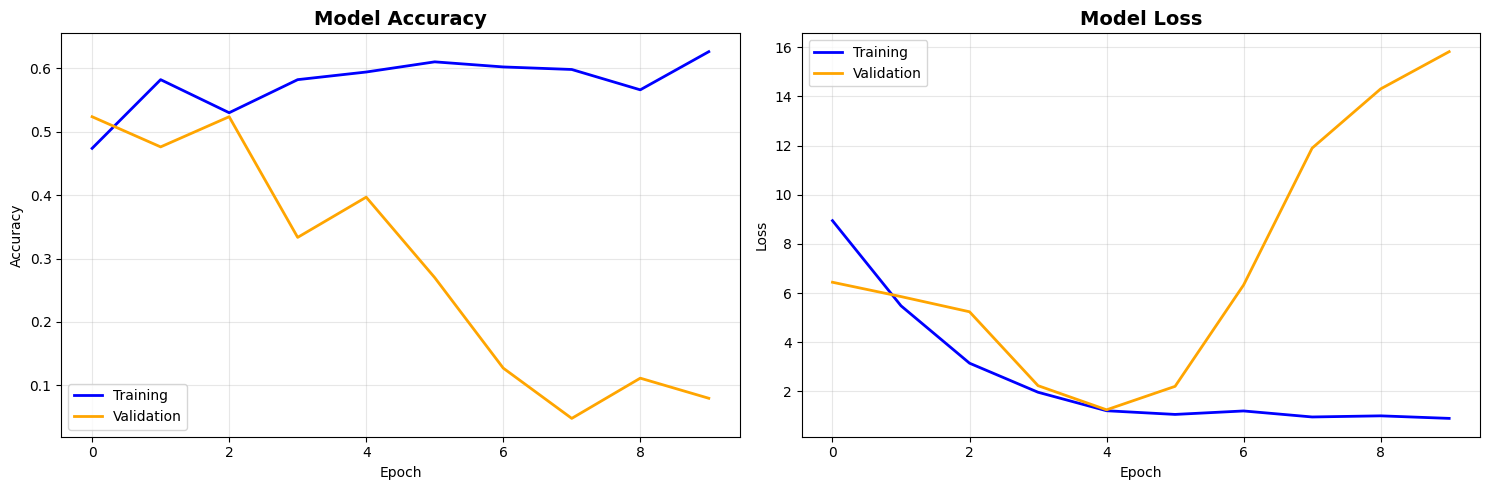

TRAINING RESULTS SUMMARY
Training completed in 10 epochs
Final Training Accuracy: 0.6265
Final Validation Accuracy: 0.0794
Final Training Loss: 0.8979
Final Validation Loss: 15.8200


In [15]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training', linewidth=2, color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='orange')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training', linewidth=2, color='blue')
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, color='orange')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed results
print("TRAINING RESULTS SUMMARY")
print(f"Training completed in {len(history.history['loss'])} epochs")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")


## 5. Model Evaluation and Analysis

Comprehensive evaluation including classification metrics, confusion matrix, and error analysis to assess model performance.

Generating predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Evaluation completed for 63 samples

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        good       0.57      0.64      0.60        33
  exc_solder       0.20      0.25      0.22        16
       spike       0.00      0.00      0.00         8
 poor_solder       0.00      0.00      0.00         6

    accuracy                           0.40        63
   macro avg       0.19      0.22      0.21        63
weighted avg       0.35      0.40      0.37        63


OVERALL PERFORMANCE METRICS
Accuracy:  0.3968 (39.7%)
Precision: 0.3481
Recall:    0.3968
F1-Score:  0.3707
Evaluation completed for 63 samples

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        good       0.57      0.64      0.60        33
  exc_solder       0.20      0.25      0.22        16
       spike       0.00      0.00      0.00         8
 poor_solder     

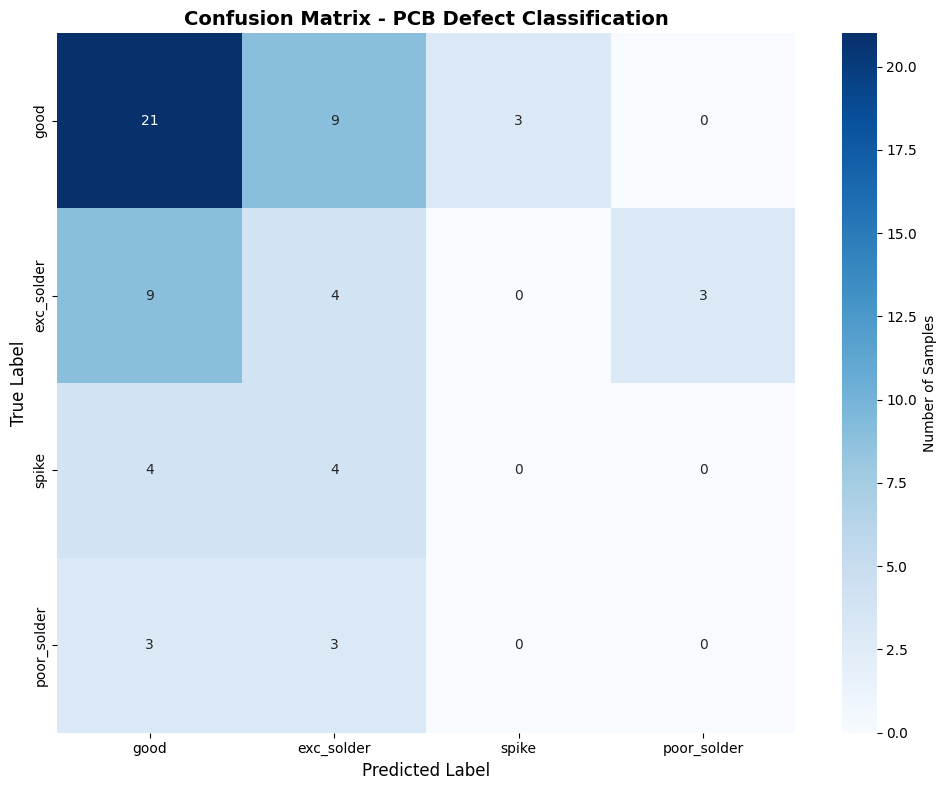


Per-class accuracy:
  good: 0.636 (63.6%)
  exc_solder: 0.250 (25.0%)
  spike: 0.000 (0.0%)
  poor_solder: 0.000 (0.0%)

Creating error analysis visualization...


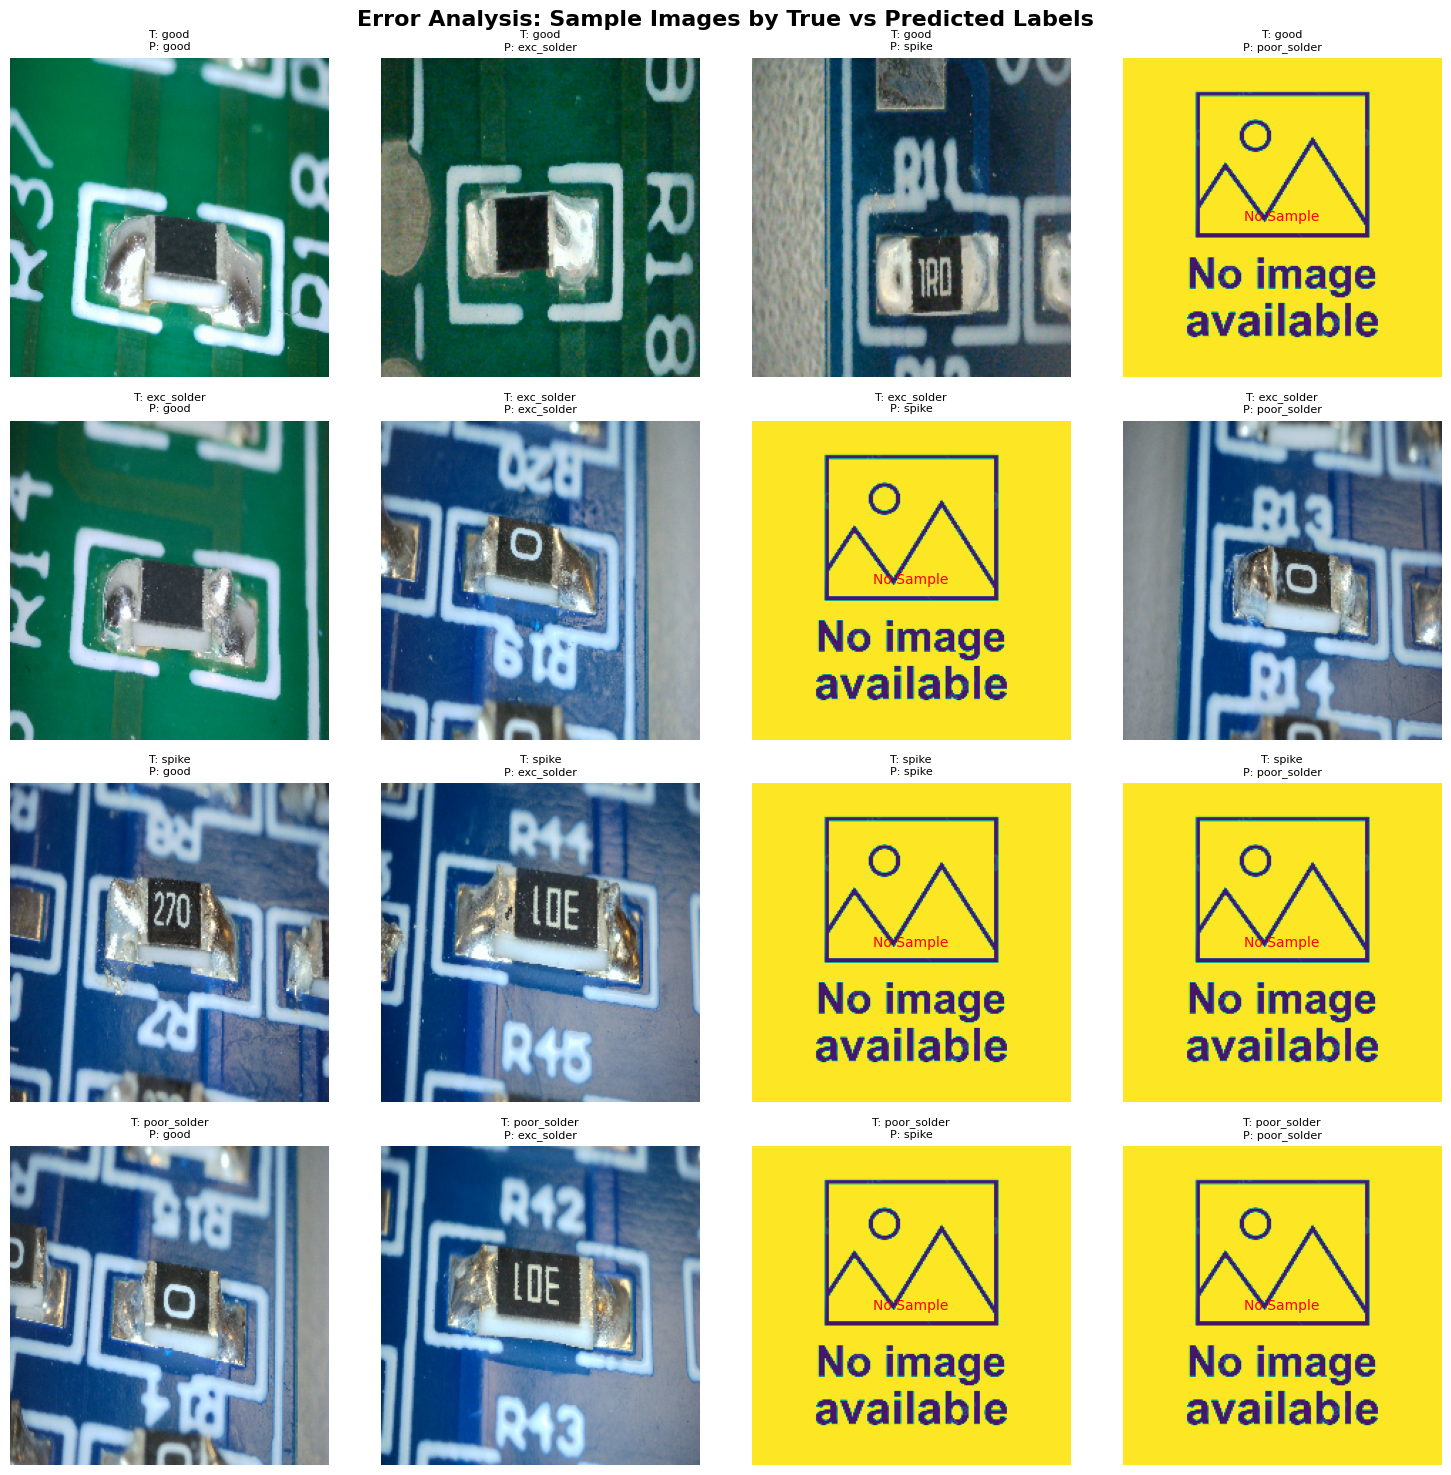


EVALUATION COMPLETED
Classification report generated
Confusion matrix created
Error analysis performed


In [16]:
def evaluate_model(model, val_generator, val_df, class_indices, validation_steps):
    # Comprehensive model evaluation
    print("Generating predictions...")
    predictions = model.predict(val_generator, steps=validation_steps, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Get true labels
    true_classes = val_df['label'].map(class_indices).values[:len(predicted_classes)]
    class_labels = list(class_indices.keys())
    
    return predicted_classes, true_classes, class_labels, predictions

# Evaluate model
val_steps = math.ceil(len(val_df) / BATCH_SIZE)
predicted_classes, true_classes, class_labels, predictions = evaluate_model(
    model, val_generator, val_df, class_indices, val_steps
)

print(f"Evaluation completed for {len(predicted_classes)} samples")

print(f"\nCLASSIFICATION REPORT")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# Calculate overall metrics
accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

print(f"\nOVERALL PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Create confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - PCB Defect Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class accuracy:")
for i, label in enumerate(class_labels):
    if cm[i].sum() > 0:
        class_acc = cm[i, i] / cm[i].sum()
        print(f"  {label}: {class_acc:.3f} ({class_acc*100:.1f}%)")

# Error analysis visualization
print(f"\nCreating error analysis visualization...")
fig, axes = plt.subplots(len(class_labels), len(class_labels), figsize=(15, 15))
fig.suptitle('Error Analysis: Sample Images by True vs Predicted Labels', fontsize=16, fontweight='bold')

for true_idx, true_label in enumerate(class_labels):
    for pred_idx, pred_label in enumerate(class_labels):
        # Find samples for this true/predicted combination
        indices = np.where((true_classes == true_idx) & (predicted_classes == pred_idx))[0]
        
        if len(indices) > 0:
            # Use the first sample found
            sample_idx = indices[0]
            image_path = val_df['filename'].iloc[sample_idx]
            
            # Load and display image
            if os.path.exists(image_path):
                sample_image = load_image_safe(image_path, TARGET_SIZE)
            else:
                sample_image = create_dummy_image()
        else:
            # No sample exists for this combination
            sample_image = create_dummy_image()
        
        # Plot the image
        ax = axes[true_idx, pred_idx]
        ax.imshow(sample_image)
        ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
        if len(indices) == 0:
            ax.text(0.5, 0.5, "No Sample", transform=ax.transAxes, 
                   ha='center', va='center', fontsize=10, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nEVALUATION COMPLETED")
print("Classification report generated")
print("Confusion matrix created") 
print("Error analysis performed")